# Model 1 SoH Predictor (NASA ARC)
EDA, training, evaluasi, dan inferensi untuk Model 1 berbasis NASA ARC zip dataset.

In [1]:
from pathlib import Path
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
from src.config import MODEL1_DATA_DIR, ARTIFACTS_DIR
from src.data_ingestion.build_dataset import build_nasa_pcoe_dataset, split_dataset_by_battery
from src.model.model1_soh import SoHPredictor
sns.set_theme(style='whitegrid')
print(MODEL1_DATA_DIR)

D:\CompSci\Lain lain\IYREF\battery-cell-matcher\data\nasa_soh_dataset


In [2]:
df = build_nasa_pcoe_dataset(MODEL1_DATA_DIR)
print(df.shape)
display(df.head())
display(df.describe(include='all').T)

(2906, 9)


,battery_id,source,cycle_count,capacity_ah,temperature_c,ocv_v,age_days,chemistry,soh
0,B0007,nasa_pcoe,1,1.891052,32.624859,3.522007,0.0,li-ion,1.000000
1,B0007,nasa_pcoe,2,1.880637,32.738210,3.531949,0.0,li-ion,0.994492
2,B0007,nasa_pcoe,3,1.880663,32.685115,3.534403,0.0,li-ion,0.994506
3,B0007,nasa_pcoe,4,1.880771,32.554748,3.534925,0.0,li-ion,0.994563
4,B0007,nasa_pcoe,5,1.879451,32.467878,3.534537,0.0,li-ion,0.993865


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
battery_id,2906,34,B0033,197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,2906,1,nasa_pcoe,2906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cycle_count,2906.0,NaN,NaN,NaN,58.609429,48.176167,1.0,20.0,45.0,88.0,197.0
capacity_ah,2881.0,NaN,NaN,NaN,1.344632,0.471986,0.0,1.162666,1.442834,1.700512,2.640149
temperature_c,2906.0,NaN,NaN,NaN,26.993086,13.736324,4.857764,11.716899,31.405073,34.00875,58.954811
ocv_v,2906.0,NaN,NaN,NaN,3.407459,0.342582,0.234723,3.367931,3.416014,3.490553,4.452558
age_days,2906.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chemistry,2906,1,li-ion,2906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soh,2881.0,NaN,NaN,NaN,0.758748,0.243236,0.0,0.713654,0.803081,0.921382,1.0


In [ ]:
plt.figure(figsize=(12,5))
for bid, g in df.groupby('battery_id'):
    plt.plot(g['cycle_count'], g['soh'], alpha=0.5)
plt.title('SoH Trajectory per Battery')
plt.xlabel('Discharge Cycle Count')
plt.ylabel('SoH')
plt.tight_layout()
plt.show()

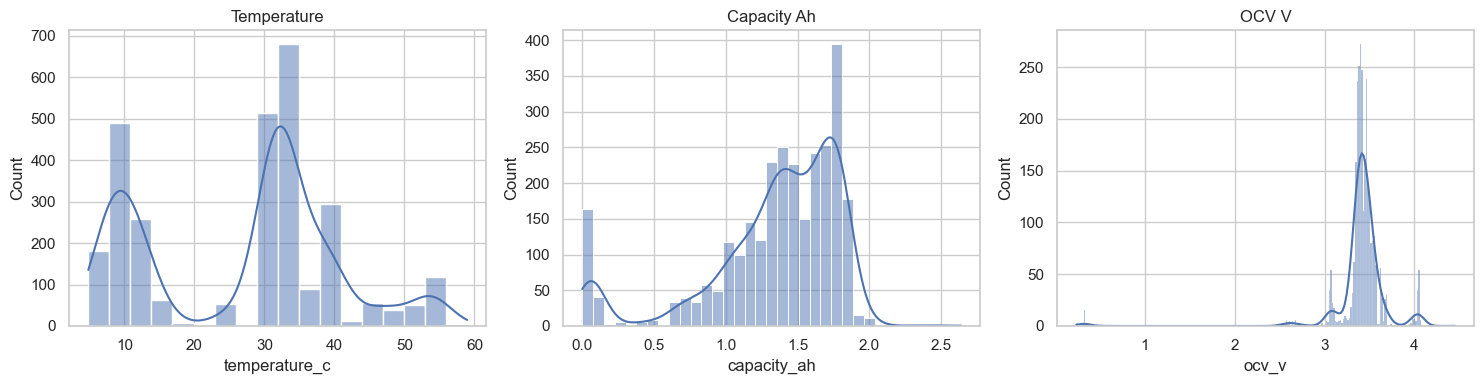

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
sns.histplot(df['temperature_c'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Temperature')
sns.histplot(df['capacity_ah'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Capacity Ah')
sns.histplot(df['ocv_v'].dropna(), kde=True, ax=axes[2])
axes[2].set_title('OCV V')
plt.tight_layout()
plt.show()

In [ ]:
train_df, val_df, test_df = split_dataset_by_battery(df)
print('train/val/test:', len(train_df), len(val_df), len(test_df))
print('batteries:', train_df['battery_id'].nunique(), val_df['battery_id'].nunique(), test_df['battery_id'].nunique())

train/val/test: 2227 266 413
batteries: 23 5 6


In [ ]:
model = SoHPredictor().fit(train_df, val_df=val_df)
print(json.dumps(model.metadata, indent=2))

{
  "model_version": "soh_predictor_v1",
  "training_rows": 2227,
  "eval_rows": 262,
  "mae": 0.11357890780494538,
  "rmse": 0.1362605205838318,
  "r2": 0.62368493799809,
  "residual_q90": 0.22212084642537097,
  "triage_thresholds": {
    "recondition_min_soh": 0.8,
    "repack_min_soh": 0.6
  }
}


In [ ]:
sample = test_df[['battery_id','ocv_v','capacity_ah','cycle_count','temperature_c','age_days','chemistry']].head(10).copy()
sample = sample.rename(columns={'battery_id':'pack_id'})
preds = pd.DataFrame(model.predict(sample.to_dict(orient='records')))
display(pd.concat([sample.reset_index(drop=True), preds], axis=1))

,pack_id,ocv_v,capacity_ah,cycle_count,temperature_c,age_days,chemistry,pack_id,predicted_soh,confidence_score,recommended_action,notes
0,B0051,3.154930,0.643474,1,13.521307,0.0,li-ion,None,0.390609,0.000000,recycle,[Prediction generated from pack-level diagnost...
1,B0051,3.351501,1.293180,2,12.329416,0.0,li-ion,None,0.775283,0.888721,repack,[Prediction generated from pack-level diagnost...
2,B0051,3.410335,1.228894,3,11.786163,0.0,li-ion,None,0.714164,0.613564,repack,[Prediction generated from pack-level diagnost...
3,B0051,3.399036,1.203903,4,11.791772,0.0,li-ion,None,0.726746,0.670205,repack,[Prediction generated from pack-level diagnost...
4,B0051,3.350463,2.330873,5,14.855344,0.0,li-ion,None,0.798065,0.991289,repack,[Prediction generated from pack-level diagnost...
5,B0051,3.550787,1.009281,6,9.407361,0.0,li-ion,None,0.788841,0.949762,repack,[Prediction generated from pack-level diagnost...
6,B0051,3.374730,0.956566,7,12.004273,0.0,li-ion,None,0.660034,0.369867,repack,[Prediction generated from pack-level diagnost...
7,B0051,3.428890,0.901956,8,11.420322,0.0,li-ion,None,0.618379,0.182333,repack,[Prediction generated from pack-level diagnost...
8,B0051,3.391239,0.889791,9,11.803568,0.0,li-ion,None,0.633195,0.249036,repack,[Prediction generated from pack-level diagnost...
9,B0051,3.458540,0.883072,10,10.939133,0.0,li-ion,None,0.622828,0.202363,repack,[Prediction generated from pack-level diagnost...


In [ ]:
SAVE = False
if SAVE:
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    df.head(1000).to_csv(ARTIFACTS_DIR / 'model1_notebook_snapshot.csv', index=False)
    print('Saved')
else:
    print('SAVE=False')

SAVE=False
